In [1]:
import os

# Step up to project root so all paths still work
os.chdir('..')
print("Working directory:", os.getcwd())

Working directory: /Users/jamespham/PycharmProjects/ekg_analyzer


In [24]:
import sys
!{sys.executable} -m pip install torch torchvision scikit-learn imbalanced-learn matplotlib seaborn numpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pickle
import os

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

%matplotlib inline

# Check if GPU is available — it will use it automatically if so
device = torch.device('mps' if torch.mps.is_available() else 'cpu')
print("Using device:", device)

Using device: mps


In [25]:
beats  = np.load('./data/processed/beats_clean.npy')
labels = np.load('./data/processed/labels_clean.npy', allow_pickle=True)

# Drop Unknown class
mask   = labels != 'Unknown'
beats  = beats[mask]
labels = labels[mask]

print("Beats shape:", beats.shape)
print("Label distribution:", Counter(labels))

# Encode labels
encoder = LabelEncoder()
y = encoder.fit_transform(labels)
X = beats

print("\nClasses:", list(encoder.classes_))

Beats shape: (33699, 216)
Label distribution: Counter({np.str_('Normal'): 27834, np.str_('PVC'): 3187, np.str_('Paced'): 2031, np.str_('Fusion'): 389, np.str_('PAC'): 258})

Classes: [np.str_('Fusion'), np.str_('Normal'), np.str_('PAC'), np.str_('PVC'), np.str_('Paced')]


In [26]:
# Normalize each beat to zero mean and unit variance
# This helps the CNN train faster and more stably
X_mean = X.mean(axis=1, keepdims=True)
X_std  = X.std(axis=1, keepdims=True) + 1e-8    # +1e-8 prevents divide by zero

X_norm = (X - X_mean) / X_std

print("Before normalization — mean:", X.mean().round(4), 
                            " std:", X.std().round(4))
print("After normalization  — mean:", X_norm.mean().round(4), 
                            " std:", X_norm.std().round(4))

Before normalization — mean: 0.0137  std: 0.344
After normalization  — mean: 0.0  std: 1.0


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Reshape for PyTorch: (samples, channels, length)
# 1 channel because it's a single-lead signal
X_train = X_train[:, np.newaxis, :]   # shape: (n, 1, 216)
X_test  = X_test[:, np.newaxis, :]

print("Train shape:", X_train.shape)
print("Test shape: ", X_test.shape)

Train shape: (26959, 1, 216)
Test shape:  (6740, 1, 216)


In [28]:
class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = ECGDataset(X_train, y_train)
test_dataset  = ECGDataset(X_test,  y_test)

In [29]:
class_counts = np.bincount(y_train)
print("Training class counts:", class_counts)

# Square root smoothing — less aggressive than 1/count
class_weights  = 1.0 / np.sqrt(class_counts)
sample_weights = class_weights[y_train]

sampler = WeightedRandomSampler(
    weights     = sample_weights,
    num_samples = len(sample_weights),
    replacement = True
)

train_loader = DataLoader(train_dataset, batch_size=64, sampler=sampler)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print("Batches per epoch:", len(train_loader))

Training class counts: [  311 22267   206  2550  1625]
Batches per epoch: 422


In [30]:
class ECG_CNN(nn.Module):
    def __init__(self, num_classes):
        super(ECG_CNN, self).__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv1d(1, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.3),

            # Block 2
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.3),
        )

        # 216 → /2 → /2 = 54 timesteps × 64 filters
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 54, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


num_classes = len(encoder.classes_)
model       = ECG_CNN(num_classes).to(device)

print(model)
print("Total parameters:", 
      sum(p.numel() for p in model.parameters() if p.requires_grad))

ECG_CNN(
  (features): Sequential(
    (0): Conv1d(1, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.3, inplace=False)
    (5): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout(p=0.3, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3456, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=5, bias=True)
  )
)
Total parameters: 453893


In [33]:
# Weighted loss — penalizes mistakes on rare classes more heavily
class_weights_np = 1.0 / np.sqrt(np.bincount(y_train))
class_weights_np = class_weights_np / class_weights_np.sum()

# Move weights to the same device as the model
criterion = nn.CrossEntropyLoss(
    weight=torch.FloatTensor(class_weights_np).to(device)
)

optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5
)

Model training

In [41]:
num_epochs    = 50
train_losses  = []
val_losses    = []
val_accuracies = []

# Early stopping settings
best_val_loss    = float('inf')
patience_counter = 0
early_stop_patience = 10

for epoch in range(num_epochs):
    # --- Training phase ---
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss    = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- Validation phase ---
    model.eval()
    val_loss = 0.0
    correct  = 0
    total    = 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss    = criterion(outputs, y_batch)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total   += y_batch.size(0)

    avg_val_loss = val_loss / len(test_loader)
    val_acc      = correct / total * 100
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)

    scheduler.step(avg_val_loss)

    print(f"Epoch {epoch+1:02d}/{num_epochs} | "
          f"Train loss: {avg_train_loss:.4f} | "
          f"Val loss: {avg_val_loss:.4f} | "
          f"Val acc: {val_acc:.1f}%")

    # Save best model and check early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        # Save the best version of the model as training progresses
        torch.save({
    'model_state_dict': model.state_dict(),
    'encoder_classes':  encoder.classes_.tolist(),   # convert to plain list
    'num_classes':      int(num_classes),             # convert to plain int
    'X_mean':           float(X_mean.mean()),         # convert to plain float
    'X_std':            float(X_std.mean()),          # convert to plain float
}, './models/ecg_cnn.pth')
        print(f"  ✓ Best model saved (val loss: {best_val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= early_stop_patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

print("CNN saved to ./models/ecg_cnn.pth")

# Load the best model before evaluation
model.load_state_dict(torch.load('./models/ecg_cnn_best.pth'))
print("\nBest model loaded for evaluation.")

Epoch 01/50 | Train loss: 0.0679 | Val loss: 0.0873 | Val acc: 97.7%
  ✓ Best model saved (val loss: 0.0873)
Epoch 02/50 | Train loss: 0.0643 | Val loss: 0.0883 | Val acc: 97.6%
Epoch 03/50 | Train loss: 0.0656 | Val loss: 0.0885 | Val acc: 97.6%
Epoch 04/50 | Train loss: 0.0657 | Val loss: 0.0896 | Val acc: 97.6%
Epoch 05/50 | Train loss: 0.0612 | Val loss: 0.0893 | Val acc: 97.6%
Epoch 06/50 | Train loss: 0.0593 | Val loss: 0.0893 | Val acc: 97.5%
Epoch 07/50 | Train loss: 0.0621 | Val loss: 0.0899 | Val acc: 97.5%
Epoch 08/50 | Train loss: 0.0630 | Val loss: 0.0906 | Val acc: 97.6%
Epoch 09/50 | Train loss: 0.0607 | Val loss: 0.0901 | Val acc: 97.6%
Epoch 10/50 | Train loss: 0.0571 | Val loss: 0.0902 | Val acc: 97.5%
Epoch 11/50 | Train loss: 0.0618 | Val loss: 0.0901 | Val acc: 97.5%

Early stopping at epoch 11
CNN saved to ./models/ecg_cnn.pth

Best model loaded for evaluation.


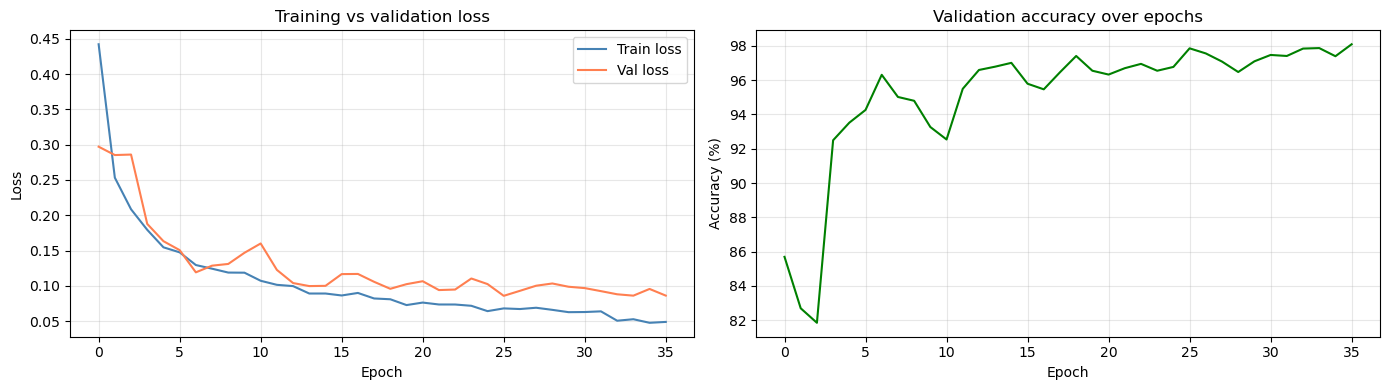

In [35]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(train_losses, label='Train loss', color='steelblue')
ax1.plot(val_losses,   label='Val loss',   color='coral')
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training vs validation loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(val_accuracies, color='green')
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.set_title("Validation accuracy over epochs")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Evaluate model on test set

In [36]:
model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print("=" * 55)
print("CLASSIFICATION REPORT — CNN")
print("=" * 55)
print(classification_report(
    all_labels, all_preds,
    target_names=encoder.classes_
))

CLASSIFICATION REPORT — CNN
              precision    recall  f1-score   support

      Fusion       0.70      0.99      0.82        78
      Normal       1.00      0.98      0.99      5567
         PAC       0.47      0.88      0.61        52
         PVC       0.94      0.97      0.95       637
       Paced       0.98      1.00      0.99       406

    accuracy                           0.98      6740
   macro avg       0.82      0.96      0.87      6740
weighted avg       0.98      0.98      0.98      6740



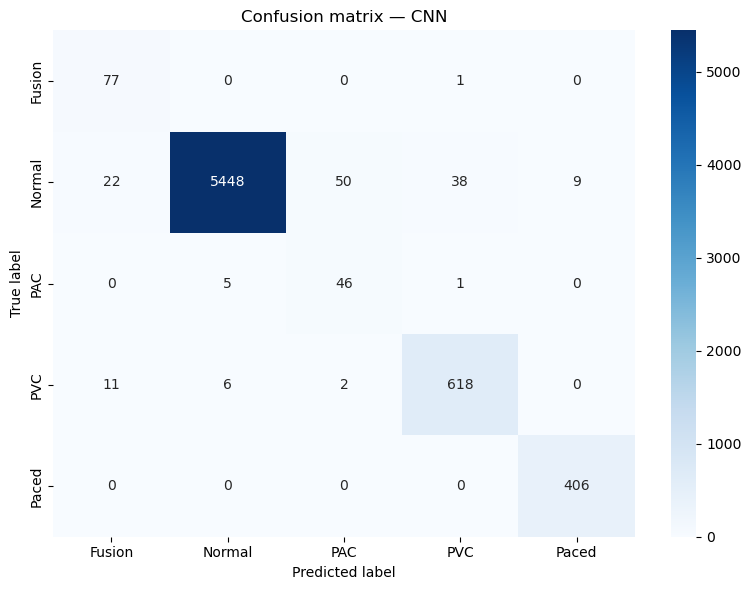

In [37]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_,
    ax=ax
)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion matrix — CNN")
plt.tight_layout()
plt.show()